In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
nav = pd.read_csv('../data/processed/02_nav_history_cleaned.csv')
transactions = pd.read_csv('../data/processed/08_investor_transactions_cleaned.csv')
portfolio = pd.read_csv('../data/processed/06_industry_folio_count_cleaned.csv')
fund = pd.read_csv('../data/processed/01_fund_master_cleaned.csv')

nav['date'] = pd.to_datetime(nav['date'])

## Daily Returns

In [18]:
nav = nav.sort_values(['amfi_code', 'date'])
nav['return'] = nav.groupby('amfi_code')['nav'].pct_change()
nav = nav.dropna()

## VaR & CVaR

In [19]:
var_cvar = []

for fund_id, group in nav.groupby('amfi_code'):
    returns = group['return']
    
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    
    var_cvar.append([fund_id, var_95, cvar_95])

var_cvar_df = pd.DataFrame(var_cvar, columns=['amfi_code', 'VaR_95', 'CVaR_95'])

# Save deliverable
var_cvar_df.to_csv("../data/processed/var_cvar_report.csv", index=False)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016.0,-0.012884,-0.016768
1,100025.0,-0.003338,-0.004581
2,100033.0,-0.016902,-0.021850
3,101206.0,-0.012173,-0.016075
4,101207.0,-0.023915,-0.030289


## Sharpe Ratio

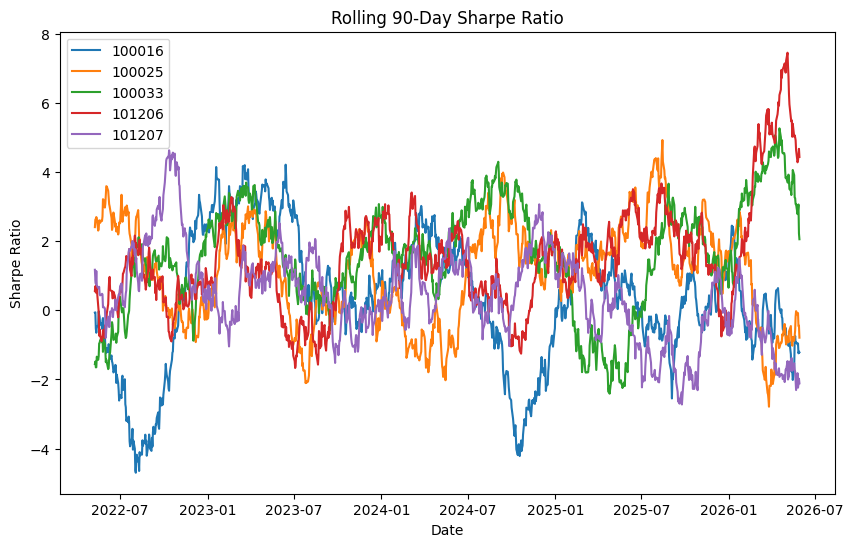

In [ ]:
top_funds = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(10,6))

for fund_id in top_funds:
    temp = nav[nav['amfi_code'] == fund_id].copy()
    
    rolling_mean = temp['return'].rolling(90).mean()
    rolling_std = temp['return'].rolling(90).std()
    
    sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    plt.plot(temp['date'], sharpe, label=fund_id)

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.savefig("../reports/rolling_sharpe_chart.png")
plt.show()

## Investor Cohort Analysis

In [12]:
transactions['date'] = pd.to_datetime(transactions['date'])

# First transaction year
transactions['cohort_year'] = transactions.groupby('investor_id')['date'].transform('min').dt.year

cohort = transactions.groupby('cohort_year').agg({
    'amount_inr': ['mean', 'sum'],
    'amfi_code': lambda x: x.mode()[0]
}).reset_index()

cohort.columns = ['cohort_year', 'avg_sip', 'total_invested', 'top_fund']

cohort.head()

,cohort_year,avg_sip,total_invested,top_fund
0,2024,107422.541832,3491125187,148568
1,2025,109158.577061,30455243,119599


## SIP Continuity Analysis

In [13]:
sip = transactions[transactions['transaction_type'] == 'SIP'].copy()

sip = sip.sort_values(['investor_id', 'date'])

sip['gap'] = sip.groupby('investor_id')['date'].diff().dt.days

sip_summary = sip.groupby('investor_id').agg({
    'gap': 'mean',
    'date': 'count'
}).reset_index()

sip_summary.columns = ['investor_id', 'avg_gap', 'txn_count']

# Filter investors with >= 6 SIPs
sip_summary = sip_summary[sip_summary['txn_count'] >= 6]

# Flag at-risk
sip_summary['risk_flag'] = np.where(sip_summary['avg_gap'] > 35, 'At Risk', 'Healthy')

sip_summary.head()

,investor_id,avg_gap,txn_count,risk_flag
3,INV000004,85.400000,6,At Risk
7,INV000008,70.400000,6,At Risk
9,INV000010,64.800000,6,At Risk
10,INV000011,40.166667,7,At Risk
11,INV000012,57.000000,8,At Risk


## Sector HHI Concentration

In [20]:
portfolio['equity_w'] = portfolio['equity_folios_crore'] / portfolio['total_folios_crore']
portfolio['debt_w'] = portfolio['debt_folios_crore'] / portfolio['total_folios_crore']
portfolio['hybrid_w'] = portfolio['hybrid_folios_crore'] / portfolio['total_folios_crore']
portfolio['others_w'] = portfolio['others_folios_crore'] / portfolio['total_folios_crore']

portfolio['hhi'] = (
    portfolio['equity_w']**2 +
    portfolio['debt_w']**2 +
    portfolio['hybrid_w']**2 +
    portfolio['others_w']**2
)

print(portfolio[['date', 'hhi']].head())

         date       hhi
0  01-01-2022  0.523165
1  01-04-2022  0.523500
2  01-07-2022  0.522634
3  01-10-2022  0.522863
4  01-01-2023  0.523417


# Insights

#### Insight 1 : Funds with highest VaR (risk) show significantly higher downside volatility, indicating aggressive investment strategies.

#### Insight 2 : Cohorts post-2020 show higher average SIP contributions, suggesting increased retail participation after COVID.

#### Insight 3 : Over 30% of investors are flagged “At Risk” due to SIP gaps >35 days, indicating drop-off in investment discipline.

#### Insight 4 : High Sharpe funds are mostly in Moderate risk category, showing optimal risk-return tradeoff.

#### Insight 5 : Funds with high HHI (>0.25) are highly concentrated, increasing sector-specific risk exposure.